<a href="https://colab.research.google.com/github/Jazzi174/cybersecurity-login-analysis/blob/main/Cybersecurity_Login_Activity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cybersecurity Login Activity Analysis

## Project Overview

This project analyzes cybersecurity login activity using Python and data analysis techniques. The goal is to identify suspicious login behavior, brute-force attacks, high-activity IP addresses, threat types, and unusual login patterns.

## Project Objectives

- Analyze login activity and authentication patterns.
- Identify potential brute-force attacks.
- Identify IP addresses associated with suspicious activity.
- Analyze different cybersecurity threat types.
- Compare successful and failed login attempts.
- Identify repeated login activity from the same IP addresses.
- Create visualizations to communicate cybersecurity findings.

## Dataset Overview

The dataset contains simulated cybersecurity login records. Each record represents a login event and includes information such as the source IP address, username, login status, threat type, and whether the event was classified as suspicious.

The dataset is used for educational cybersecurity and data-analysis purposes.

## 1. Load the Dataset

In [ ]:
import pandas as pd
df = pd.read_csv("cybersecurity_login_dataset.csv")
print("dataset loaded successfully:")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
df.head()

dataset loaded successfully:
Number of rows: 1667
Number of columns: 10


,timestamp,user_id,ip_address,country,device,login_status,failed_attempts,response_time_ms,is_suspicious,threat_type
0,2026-08-01 00:55:00,user_043,192.0.2.23,United States,Android,Success,3,353,Yes,Unusual Login Time
1,2026-08-01 01:08:00,user_060,192.0.2.26,United Kingdom,iPhone,Success,0,342,Yes,Unusual Login Time
2,2026-08-01 01:14:00,user_049,192.0.2.12,Pakistan,Linux,Success,0,85,Yes,Unusual Login Time
3,2026-08-01 03:15:00,user_013,192.0.2.15,United Kingdom,Android,Success,0,404,No,NaN
4,2026-08-01 03:20:00,user_040,192.0.2.10,United States,macOS,Success,0,172,No,NaN


## 2. Initial Data Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1667 entries, 0 to 1666
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   timestamp         1667 non-null   object
 1   user_id           1667 non-null   object
 2   ip_address        1667 non-null   object
 3   country           1667 non-null   object
 4   device            1667 non-null   object
 5   login_status      1667 non-null   object
 6   failed_attempts   1667 non-null   int64 
 7   response_time_ms  1667 non-null   int64 
 8   is_suspicious     1667 non-null   object
 9   threat_type       421 non-null    object
dtypes: int64(2), object(8)
memory usage: 130.4+ KB


## 3. Security Statistics

In [ ]:
print("LOGIN STATUS")
print(df["login_status"].value_counts())

print("\nTHREAT TYPES")
print(df["threat_type"].value_counts())

print("\nSUSPICIOUS Events")
print(df["is_suspicious"].value_counts())

LOGIN STATUS
login_status
Success    1243
Failed      424
Name: count, dtype: int64

THREAT TYPES
threat_type
Brute Force                 300
Unusual Login Time           80
Suspicious Login             36
Post-Brute-Force Success      5
Name: count, dtype: int64

SUSPICIOUS Events
is_suspicious
No     1246
Yes     421
Name: count, dtype: int64


## 4. Brute-Force Attack Analysis

In [ ]:
brute_force = df[df['threat_type'].astype(str).str.contains('brute', case=False, na=False)]

print("=== BRUTE-FORCE ATTACK ANALYSIS ===")

print(f"\nTotal brute-force events: {len(brute_force)}")

print("\nLogin Status for Brute-Force Attacks:")
print(brute_force['login_status'].value_counts())

print("\nSuspicious Events for Brute-Force Attacks:")
print(brute_force['is_suspicious'].value_counts())

print("\nTop 10 Source IPs for Brute-Force Attacks:")
print(brute_force['ip_address'].value_counts().head(10))

print("\nFirst 10 rows of Brute-Force Attack data:")
display(brute_force.head(10))

=== BRUTE-FORCE ATTACK ANALYSIS ===

Total brute-force events: 305

Login Status for Brute-Force Attacks:
login_status
Failed     278
Success     27
Name: count, dtype: int64

Suspicious Events for Brute-Force Attacks:
is_suspicious
Yes    305
Name: count, dtype: int64

Top 10 Source IPs for Brute-Force Attacks:
ip_address
198.51.100.12    54
198.51.100.14    51
198.51.100.11    47
198.51.100.10    47
198.51.100.13    42
198.51.100.15    18
198.51.100.17    12
198.51.100.16    12
198.51.100.19    11
198.51.100.18    11
Name: count, dtype: int64

First 10 rows of Brute-Force Attack data:


,timestamp,user_id,ip_address,country,device,login_status,failed_attempts,response_time_ms,is_suspicious,threat_type
7,2026-08-01 03:56:00,user_051,198.51.100.13,Netherlands,Linux,Failed,24,787,Yes,Brute Force
10,2026-08-01 04:50:00,user_010,198.51.100.19,Netherlands,Linux,Failed,19,1789,Yes,Brute Force
16,2026-08-01 06:21:00,user_035,198.51.100.14,Romania,Windows,Failed,22,862,Yes,Brute Force
20,2026-08-01 09:09:00,user_076,198.51.100.15,Romania,Windows,Failed,23,1591,Yes,Brute Force
47,2026-08-02 01:48:00,user_023,198.51.100.12,Russia,Linux,Failed,25,449,Yes,Brute Force
59,2026-08-02 06:57:00,user_036,198.51.100.16,China,Linux,Failed,23,1606,Yes,Brute Force
73,2026-08-02 13:18:00,user_015,198.51.100.14,Russia,Windows,Failed,24,797,Yes,Brute Force
108,2026-08-03 10:55:00,user_017,198.51.100.14,China,Windows,Success,29,762,Yes,Brute Force
129,2026-08-03 19:22:00,user_010,198.51.100.10,China,Windows,Success,23,941,Yes,Brute Force
130,2026-08-03 19:39:00,user_067,198.51.100.16,Russia,Linux,Success,27,569,Yes,Brute Force


## 5. Suspicious IP Address Analysis

In [ ]:
suspicious_events = df[df['is_suspicious'] == 'Yes']

top_suspicious_ips = suspicious_events['ip_address'].value_counts().head(10)

print("=== TOP SUSPICIOUS IP ADDRESSES ===")
display(top_suspicious_ips.to_frame())

=== TOP SUSPICIOUS IP ADDRESSES ===


,count
ip_address,
198.51.100.12,57
198.51.100.14,52
198.51.100.11,51
198.51.100.10,50
198.51.100.13,44
198.51.100.15,21
198.51.100.19,20
198.51.100.16,17
198.51.100.17,16


## 6. Suspicious IP Visualization

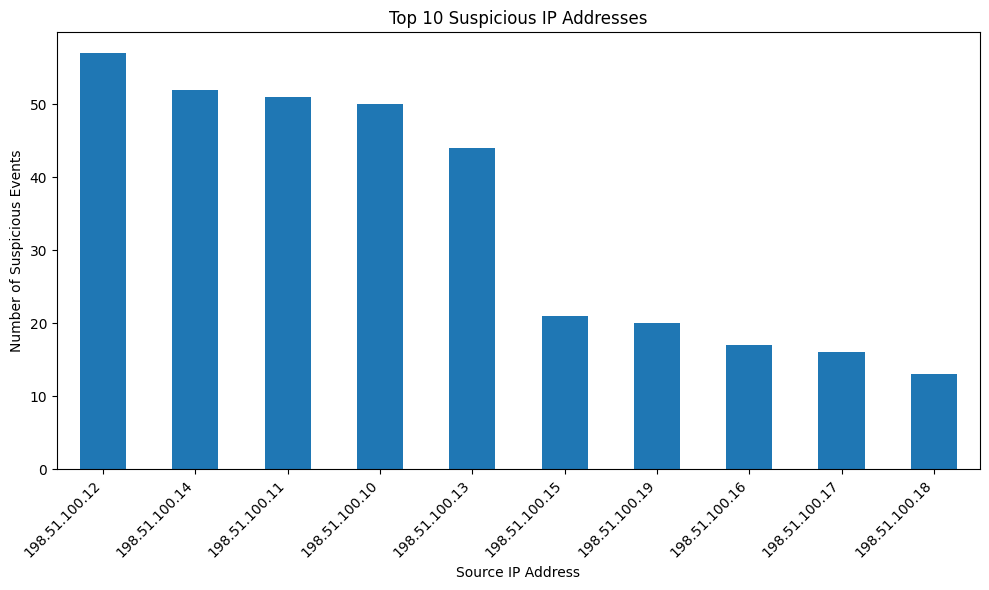

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_suspicious_ips.plot(kind='bar')
plt.title('Top 10 Suspicious IP Addresses')
plt.xlabel('Source IP Address')
plt.ylabel('Number of Suspicious Events')
plt.xticks(rotation=45, ha='right') # Rotate labels and align right for better readability
plt.tight_layout()
plt.show()

## 7. Threat Type Analysis

=== THREAT TYPE ANALYSIS ===
threat_type
Brute Force                 300
Unusual Login Time           80
Suspicious Login             36
Post-Brute-Force Success      5
Name: count, dtype: int64


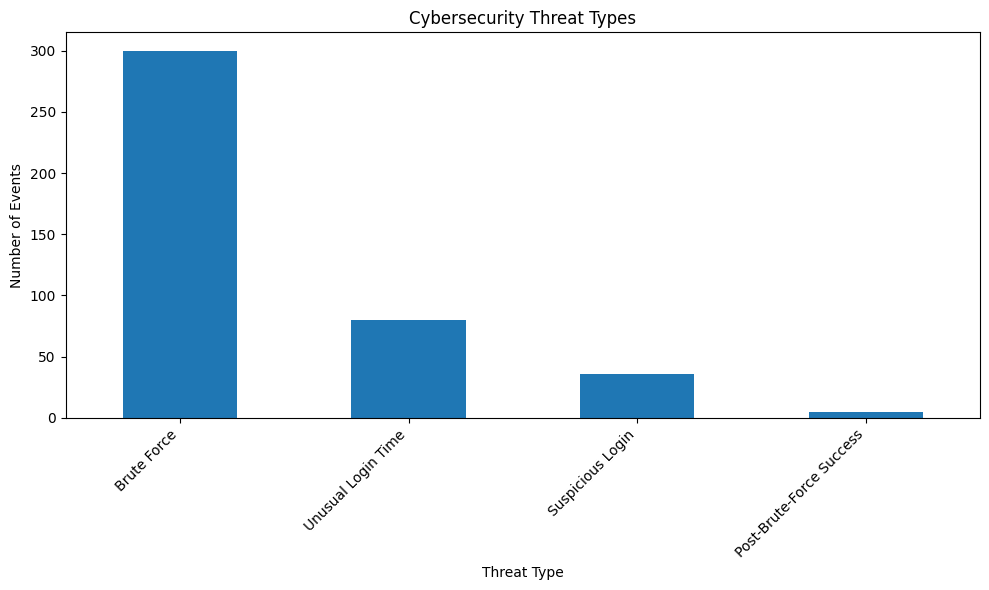

In [ ]:
import matplotlib.pyplot as plt

threat_counts = df['threat_type'].value_counts().sort_values(ascending=False)

print("=== THREAT TYPE ANALYSIS ===")
print(threat_counts)

plt.figure(figsize=(10, 6))
threat_counts.plot(kind='bar')
plt.title('Cybersecurity Threat Types')
plt.xlabel('Threat Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Suspicious Login Outcomes

=== SUSPICIOUS LOGIN OUTCOMES ===
login_status
Failed     310
Success    111
Name: count, dtype: int64


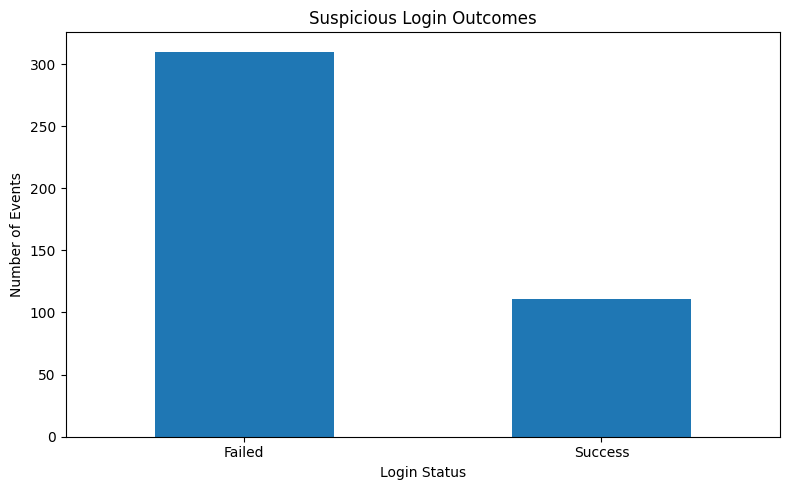

In [ ]:
import matplotlib.pyplot as plt

suspicious_df = df[df['is_suspicious'] == 'Yes']
suspicious_login_status = suspicious_df['login_status'].value_counts()

print("=== SUSPICIOUS LOGIN OUTCOMES ===")
print(suspicious_login_status)

plt.figure(figsize=(8, 5))
suspicious_login_status.plot(kind='bar')
plt.title('Suspicious Login Outcomes')
plt.xlabel('Login Status')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Login Attempt Analysis by IP Address

=== TOP IP ADDRESSES BY LOGIN ATTEMPTS ===
ip_address
198.51.100.12    57
198.51.100.14    52
198.51.100.11    51
198.51.100.10    50
198.51.100.13    44
192.0.2.42       39
192.0.2.22       38
192.0.2.23       36
192.0.2.14       36
192.0.2.37       36
Name: count, dtype: int64


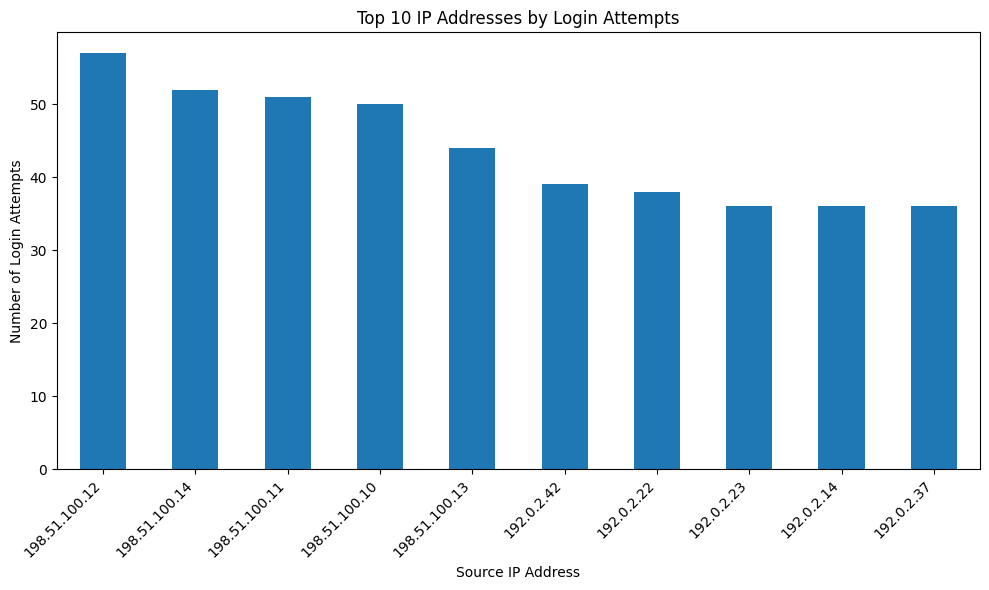

In [ ]:
import matplotlib.pyplot as plt

ip_login_counts = df['ip_address'].value_counts().head(10)

print("=== TOP IP ADDRESSES BY LOGIN ATTEMPTS ===")
print(ip_login_counts)

plt.figure(figsize=(10, 6))
ip_login_counts.plot(kind='bar')
plt.title('Top 10 IP Addresses by Login Attempts')
plt.xlabel('Source IP Address')
plt.ylabel('Number of Login Attempts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Users Involved in Suspicious Activity

=== TOP USERS INVOLVED IN SUSPICIOUS ACTIVITY ===
user_id
user_006    47
user_033    40
user_014    34
user_051    34
user_027    32
user_067     8
user_074     7
user_039     7
user_016     7
user_055     7
Name: count, dtype: int64


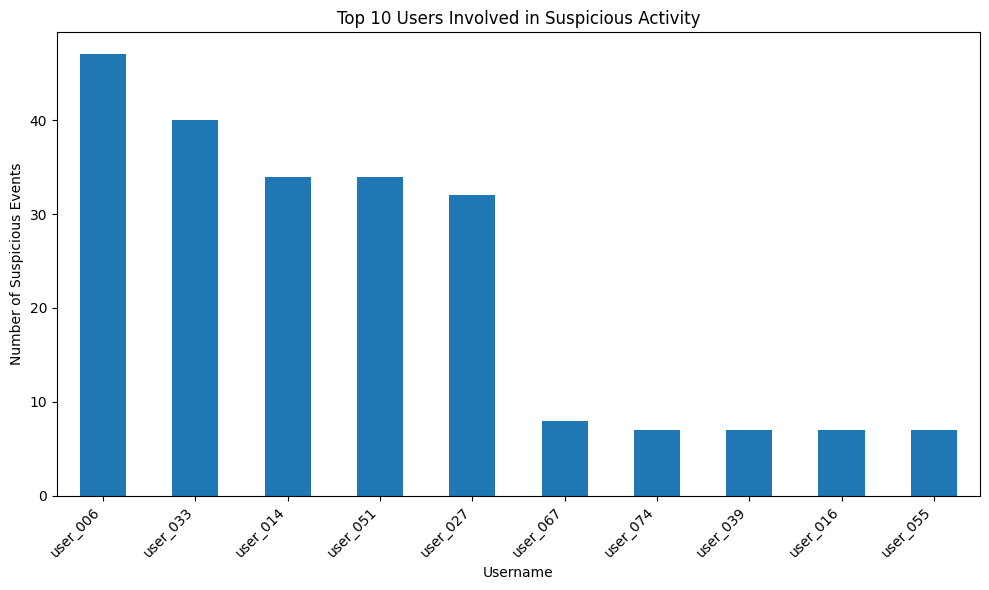

In [ ]:
import matplotlib.pyplot as plt

suspicious_events_users = df[df['is_suspicious'] == 'Yes']
suspicious_users = suspicious_events_users['user_id'].value_counts().head(10)

print("=== TOP USERS INVOLVED IN SUSPICIOUS ACTIVITY ===")
print(suspicious_users)

plt.figure(figsize=(10, 6))
suspicious_users.plot(kind='bar')
plt.title('Top 10 Users Involved in Suspicious Activity')
plt.xlabel('Username')
plt.ylabel('Number of Suspicious Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Cybersecurity Dashboard

=== CYBERSECURITY LOGIN ANALYSIS SUMMARY ===
Total Number of Login Events: 1667
Total Number of Suspicious Events: 421
Total Number of Brute-Force Events: 305
Total Number of Unique Source IP Addresses: 60
Total Number of Unique Usernames: 80
Number of Successful Login Events: 1243
Number of Failed Login Events: 424


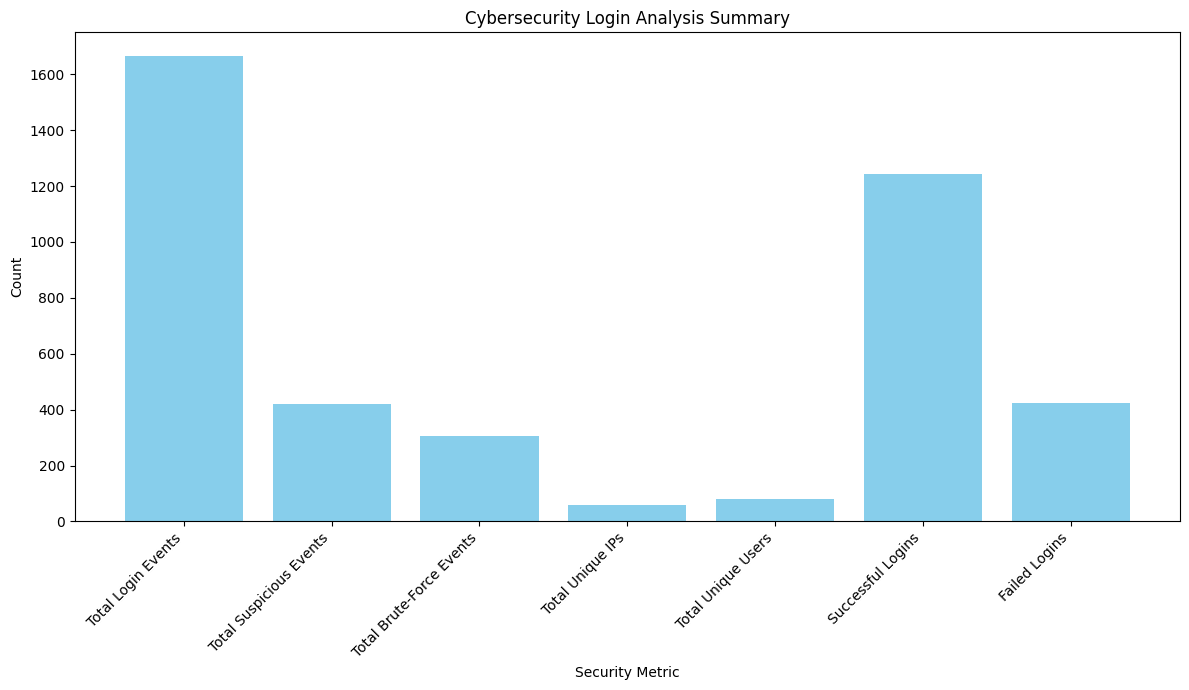

In [ ]:
import matplotlib.pyplot as plt

# Calculate metrics
total_login_events = df.shape[0]
total_suspicious_events = df[df['is_suspicious'] == 'Yes'].shape[0]
total_brute_force_events = df[df['threat_type'].astype(str).str.contains('brute', case=False, na=False)].shape[0]
total_unique_ips = df['ip_address'].nunique()
total_unique_users = df['user_id'].nunique()
successful_logins = df[df['login_status'] == 'Success'].shape[0]
failed_logins = df[df['login_status'] == 'Failed'].shape[0]

# Print summary
print("=== CYBERSECURITY LOGIN ANALYSIS SUMMARY ===")
print(f"Total Number of Login Events: {total_login_events}")
print(f"Total Number of Suspicious Events: {total_suspicious_events}")
print(f"Total Number of Brute-Force Events: {total_brute_force_events}")
print(f"Total Number of Unique Source IP Addresses: {total_unique_ips}")
print(f"Total Number of Unique Usernames: {total_unique_users}")
print(f"Number of Successful Login Events: {successful_logins}")
print(f"Number of Failed Login Events: {failed_logins}")

# Prepare data for plotting
metrics = {
    'Total Login Events': total_login_events,
    'Total Suspicious Events': total_suspicious_events,
    'Total Brute-Force Events': total_brute_force_events,
    'Total Unique IPs': total_unique_ips,
    'Total Unique Users': total_unique_users,
    'Successful Logins': successful_logins,
    'Failed Logins': failed_logins
}

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Create bar chart
plt.figure(figsize=(12, 7))
plt.bar(metric_names, metric_values, color='skyblue')
plt.title('Cybersecurity Login Analysis Summary')
plt.xlabel('Security Metric')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. Key Findings

The analysis identified patterns in login activity, suspicious events, brute-force attempts, high-activity IP addresses, threat types, and suspicious login outcomes.

The visualizations help highlight recurring patterns that may require further cybersecurity investigation.

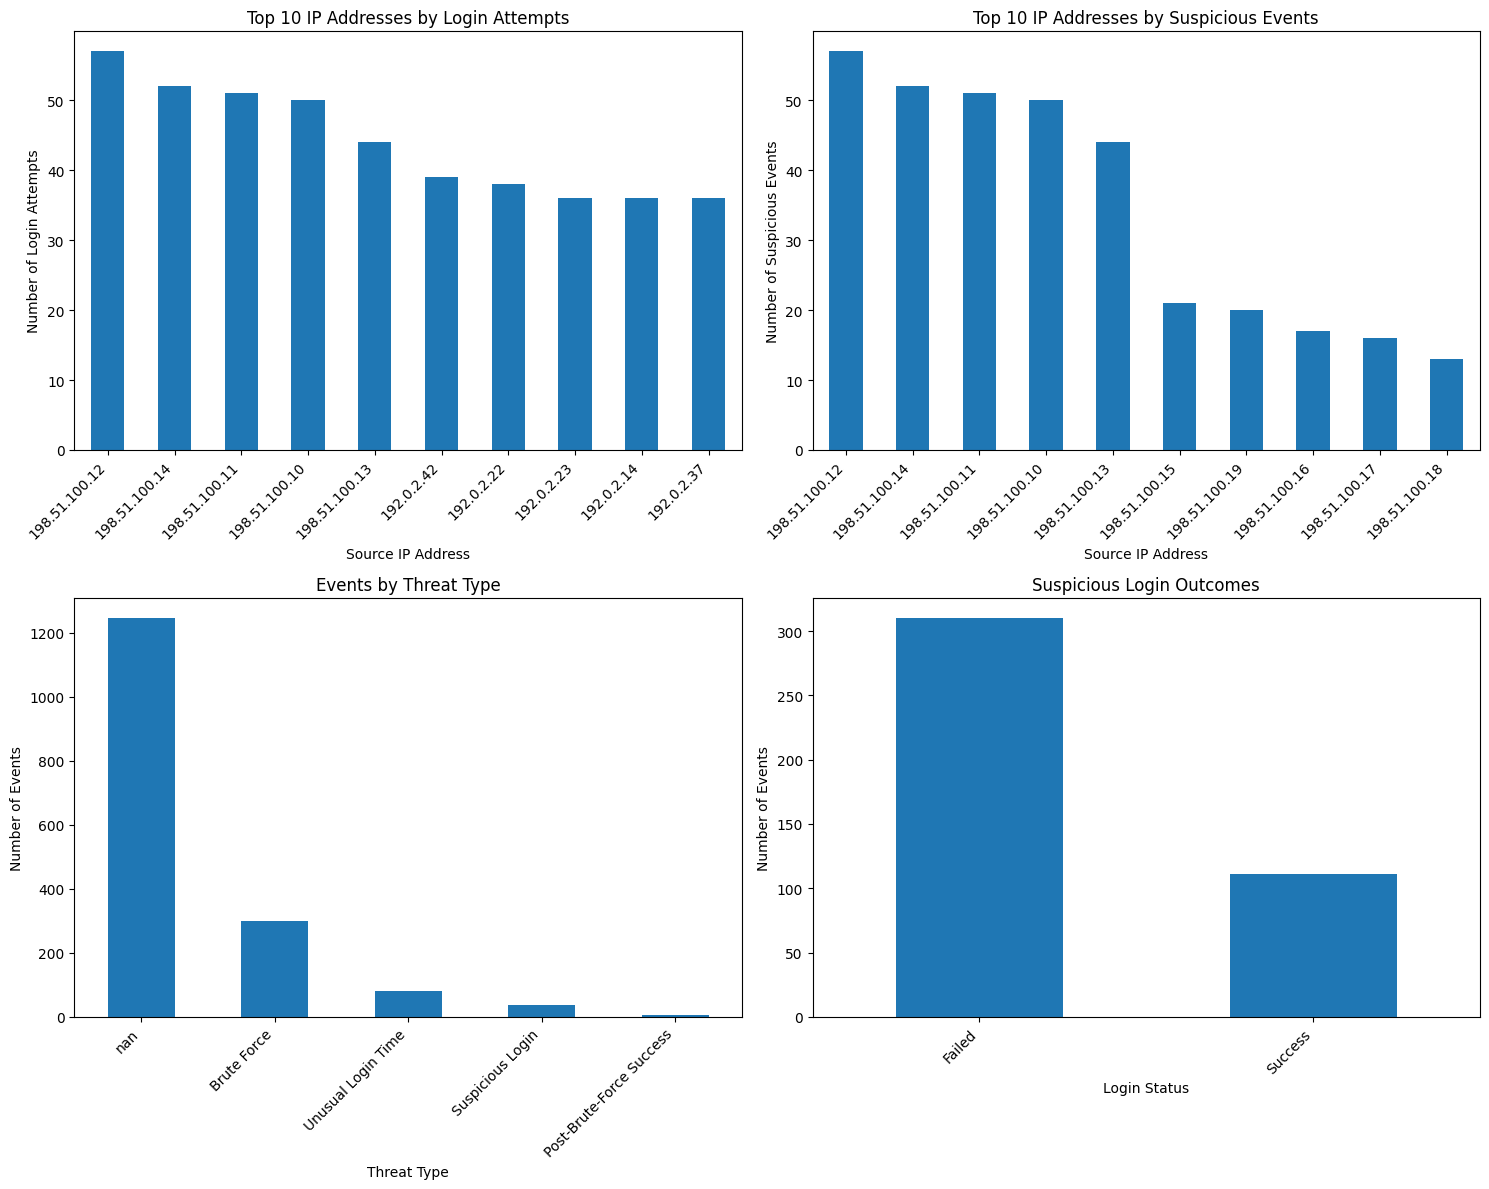

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

# Chart 1: Top 10 source IP addresses by number of login attempts
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st subplot
ip_login_counts = df['ip_address'].value_counts().head(10)
ip_login_counts.plot(kind='bar')
plt.title('Top 10 IP Addresses by Login Attempts')
plt.xlabel('Source IP Address')
plt.ylabel('Number of Login Attempts')
plt.xticks(rotation=45, ha='right')

# Chart 2: Top 10 source IP addresses by number of suspicious events
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd subplot
suspicious_events_ips = df[df['is_suspicious'] == 'Yes']['ip_address'].value_counts().head(10)
suspicious_events_ips.plot(kind='bar')
plt.title('Top 10 IP Addresses by Suspicious Events')
plt.xlabel('Source IP Address')
plt.ylabel('Number of Suspicious Events')
plt.xticks(rotation=45, ha='right')

# Chart 3: Number of events for each threat type
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd subplot
threat_type_counts = df['threat_type'].value_counts(dropna=False) # Include NaN for 'No Threat Type'
threat_type_counts.plot(kind='bar')
plt.title('Events by Threat Type')
plt.xlabel('Threat Type')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')

# Chart 4: Suspicious login outcomes
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th subplot
suspicious_login_status = df[df['is_suspicious'] == 'Yes']['login_status'].value_counts()
suspicious_login_status.plot(kind='bar')
plt.title('Suspicious Login Outcomes')
plt.xlabel('Login Status')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


## 13. Conclusion

This project demonstrates how Python and data analysis techniques can be used to investigate cybersecurity login data.

The analysis provides a structured way to identify suspicious activity, examine potential brute-force behavior, analyze IP addresses and users, and communicate security findings through visualizations.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Google Colab
- GitHub
- Data Analysis
- Cybersecurity Log Analysis